# PopOut — Decision Tree AI Pipeline

This notebook trains and evaluates ID3 decision-tree agents for the PopOut board game.
It is **model-agnostic**: switch `ACTIVE_MODEL` in the toggle cell (cell 2) to run the
full pipeline on any of the four dataset versions without changing anything else.

## How the toggle works

```python
ACTIVE_MODEL = 'v1'   # ← change to 'v1', 'v2', 'v3', or 'v4'
```

Each version has its own entry in `MODEL_CONFIGS` controlling:

| Key | Meaning |
|---|---|
| `feat_depth` | Max depth for the ID3 tree trained on engineered features |
| `raw_depth` | Max depth for the raw-cells-only tree |
| `filter_can_win` | Whether to remove `can_win=1` positions before training (v4 only — wrapper handles them) |
| `raw_oversample` | Proven-position oversampling factor for the raw model (10× for small datasets, 4× for v4) |

Results are cached per version under `data/generated/{VERSION}/results/`.
Re-running a cell skips the expensive computation and loads from disk instead.

## Pipeline sections

1. **Dataset generation** — parallel self-play with MCTS-Solver records `(board state, best move)` pairs
2. **Data exploration** — class distribution and feature overview
3. **ID3 classifier** — train under three train/test splits, measure accuracy
4. **Feature sweep** — how accuracy scales with the number of top-IG features used
5. **Win-rate evaluation** — how often the tree beats FlatNumbaSolverMCTS in actual play
6. **Cross-version comparison** — all four versions evaluated head-to-head
---

**Inteligência Artificial 2025/2026 — Trabalho Prático**

**Grupo**:
- [ALUNO 1: Nome Completo, Número Mecanográfico]
- [ALUNO 2: Nome Completo, Número Mecanográfico]
- [ALUNO 3: Nome Completo, Número Mecanográfico]

**Repositório**: <https://github.com/Difl4/popout-ai>


In [61]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.decision_tree.id3.learner import ID3Classifier
from src.decision_tree.dataset_generator import generate_dataset_parallel
from src.engine.standard.bitboard import PopOutBoard
from src.engine.standard.rules import evaluate_after_move, extended_features

plt.style.use('ggplot')
print(f'CPU cores available: {os.cpu_count()}')

CPU cores available: 20


In [ ]:
import json as _json

# ── Model toggle ──────────────────────────────────────────────────────────────
# Change ACTIVE_MODEL to switch datasets. Pre-saved results are loaded
# automatically so expensive sections are skipped on subsequent runs.
# Available keys: 'v1', 'v2', 'v3', 'v4'
AVAILABLE_MODELS = {
    'v1': 'v1_3000games_100k',
    'v2': 'v2_5000games_100k',
    'v3': 'v3_5000games_tiered',
    'v4': 'v4_75k_100k',
}

# Depths match the trained .pkl files for each version
MODEL_CONFIGS = {
    'v1': {'feat_depth': 10, 'raw_depth': 18, 'filter_can_win': False, 'raw_oversample': 10},
    'v2': {'feat_depth': 10, 'raw_depth': 18, 'filter_can_win': False, 'raw_oversample': 10},
    'v3': {'feat_depth': 10, 'raw_depth': 18, 'filter_can_win': False, 'raw_oversample': 10},
    'v4': {'feat_depth': 15, 'raw_depth': 20, 'filter_can_win': True,  'raw_oversample': 4},
}

ACTIVE_MODEL = 'v4'   # ← change this to switch models

VERSION    = AVAILABLE_MODELS[ACTIVE_MODEL]
FEAT_DEPTH = MODEL_CONFIGS[ACTIVE_MODEL]['feat_depth']
RAW_DEPTH  = MODEL_CONFIGS[ACTIVE_MODEL]['raw_depth']
FILTER_CAN_WIN = MODEL_CONFIGS[ACTIVE_MODEL]['filter_can_win']
RAW_OVERSAMPLE = MODEL_CONFIGS[ACTIVE_MODEL]['raw_oversample']

# Per-model results live under data/generated/{VERSION}/results/
# Shared cross-version results live under data/generated/shared_results/
_results_dir  = Path(f'../data/generated/{VERSION}/results')
_shared_dir   = Path('../data/generated/shared_results')
_acc_path     = _results_dir / 'accuracy_results.json'
_sweep_path   = _results_dir / 'sweep_results.json'
_winrate_path = _results_dir / 'winrate_results.json'
_cross_path   = _shared_dir  / 'cross_version_winrate.json'

_saved_accuracy = None
_saved_sweep    = None
_saved_winrate  = None

if _acc_path.exists():
    with open(_acc_path) as _f:
        _saved_accuracy = _json.load(_f)
    print(f'[{ACTIVE_MODEL}] Pre-saved accuracy results loaded  ({VERSION})')
else:
    print(f'[{ACTIVE_MODEL}] No saved accuracy results — will compute and save on first run.')

if _sweep_path.exists():
    with open(_sweep_path) as _f:
        _saved_sweep = _json.load(_f)
    print(f'[{ACTIVE_MODEL}] Pre-saved sweep results loaded  ({VERSION})')
else:
    print(f'[{ACTIVE_MODEL}] No saved sweep results — will compute and save on first run.')

if _winrate_path.exists():
    with open(_winrate_path) as _f:
        _saved_winrate = _json.load(_f)
    print(f'[{ACTIVE_MODEL}] Pre-saved win-rate results loaded  ({VERSION})')
else:
    print(f'[{ACTIVE_MODEL}] No saved win-rate results — will compute and save on first run.')

if _cross_path.exists():
    print('Pre-saved cross-version results found  (shared_results/)')
else:
    print('No saved cross-version results — will compute and save on first run (section 6).')

print(f'\nActive model : {ACTIVE_MODEL}  →  {VERSION}  '
      f'(feat_depth={FEAT_DEPTH}, raw_depth={RAW_DEPTH}, filter_can_win={FILTER_CAN_WIN}, raw_oversample={RAW_OVERSAMPLE})')


[v3] Pre-saved accuracy results loaded  (v3_5000games_tiered)
[v3] Pre-saved sweep results loaded  (v3_5000games_tiered)
[v3] Pre-saved win-rate results loaded  (v3_5000games_tiered)
Pre-saved cross-version results found  (shared_results/)

Active model : v3  →  v3_5000games_tiered  (feat_depth=10, raw_depth=18, filter_can_win=False, raw_oversample=10)


## 1. Dataset Generation

Each worker plays one **complete game** and records every position as a
`(board state, best move)` training pair.

**Oracle** (`ReuseFlatNumbaSolverMCTS`): plays one fixed side and labels every
position — including the opponent's turns. Tree reuse is enabled between the
oracle's consecutive turns so later positions inherit the prior search and
effectively receive more iterations, discovering more proven positions.

**Opponent** (`FlatNumbaSolverMCTS`, fresh each call): used to label positions on
the opponent's turns. A fresh search is correct here because the opponent may have
blundered to reach the position via a path the oracle never explored.

**Opening diversity**: the opponent's first 2 moves are forced, cycling through all
49 column combinations (7×7) so every opening is systematically covered.

**Blunder tiers**: games are split into tiers with different blunder rates, covering
near-optimal through weak opponent play in equal measure.

**Checkpointing**: progress is saved to disk every 500 games. Re-running this cell
automatically resumes from the last checkpoint if interrupted.

> Dataset generation parameters (game count, oracle iterations, blunder tiers) are
> set at the top of this cell and vary by version. If the dataset CSV already exists
> the cell loads it instantly and skips generation.


In [63]:
N_GAMES          = 75_000   # only relevant if regenerating (v4 settings)
ORACLE_ITERS     = 100_000
CHECKPOINT_EVERY = 500
# VERSION is set by the model toggle cell above

DATA_PATH     = Path(f'../data/generated/{VERSION}/popout_dt_dataset.csv')
PROGRESS_PATH = DATA_PATH.with_suffix('.progress')
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

BLUNDER_TIERS = [(1/3, 0.05), (1/3, 0.25), (1/3, 0.50)]

if DATA_PATH.exists() and not PROGRESS_PATH.exists():
    # Completed run — just load
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded existing dataset: {len(df):,} rows <- {DATA_PATH}')
    print('Delete the file and re-run to regenerate.')
else:
    games_done = int(PROGRESS_PATH.read_text()) if PROGRESS_PATH.exists() else 0

    if games_done > 0:
        print(f'Resuming: {games_done:,}/{N_GAMES:,} games already done')
    else:
        print(f'Starting fresh: {N_GAMES:,} games | oracle={ORACLE_ITERS:,} iter/move | workers={os.cpu_count()}')

    t_run = time.perf_counter()

    for batch_start in range(games_done, N_GAMES, CHECKPOINT_EVERY):
        batch_end = min(batch_start + CHECKPOINT_EVERY, N_GAMES)

        print(f'  Games {batch_start+1:>5}–{batch_end:<5} / {N_GAMES:,} ...', end='  ', flush=True)
        t0 = time.perf_counter()

        batch_df = generate_dataset_parallel(
            n_games=batch_end - batch_start,
            oracle_iterations=ORACLE_ITERS,
            blunder_tiers=BLUNDER_TIERS,
            seed=42 + batch_start,
        )

        # Append to the final CSV — header only on the very first write
        batch_df.to_csv(DATA_PATH, mode='a', header=not DATA_PATH.exists(), index=False)
        # Update progress counter — resume reads this to skip ahead
        PROGRESS_PATH.write_text(str(batch_end))

        print(f'{len(batch_df):>7,} rows | {time.perf_counter()-t0:>6.0f} s | {batch_end:,}/{N_GAMES:,} games done')

    df = pd.read_csv(DATA_PATH)
    PROGRESS_PATH.unlink()  # absence of this file signals a clean completed run

    print(f'\nDone in {(time.perf_counter()-t_run)/3600:.2f} h  |  {len(df):,} rows  |  {len(df)/N_GAMES:.1f} rows/game')
    print(f'Saved -> {DATA_PATH}')

print(f'\nDataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded existing dataset: 193,058 rows <- ../data/generated/v3_5000games_tiered/popout_dt_dataset.csv
Delete the file and re-run to regenerate.

Dataset: 193,058 rows x 52 columns


## 2. Data Exploration

In [64]:
TARGET       = 'best_move'
# is_proven is metadata used only for oversampling — never a tree input feature
FEATURE_COLS = [c for c in df.columns if c not in (TARGET, 'is_proven')]

print(f'Features : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ... {FEATURE_COLS[-1]})')
print(f'Classes  : {df[TARGET].nunique()} unique moves')
if 'is_proven' in df.columns:
    n_proven = int(df['is_proven'].sum())
    print(f'Proven positions: {n_proven} / {len(df)} ({n_proven/len(df):.1%})')
print()
df.head(3)

Features : 50  (['cell_0_0', 'cell_0_1', 'cell_0_2', 'cell_0_3', 'cell_0_4'] ... opp_wins_next)
Classes  : 14 unique moves
Proven positions: 75830 / 193058 (39.3%)



,cell_0_0,cell_0_1,cell_0_2,cell_0_3,cell_0_4,cell_0_5,cell_0_6,cell_1_0,cell_1_1,cell_1_2,...,current_player,threats_me,threats_opp,center_me,center_opp,phase,can_win,opp_wins_next,best_move,is_proven
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,drop_3,0
1,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,1,0,0,0,drop_3,0
2,2,0,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,drop_4,0


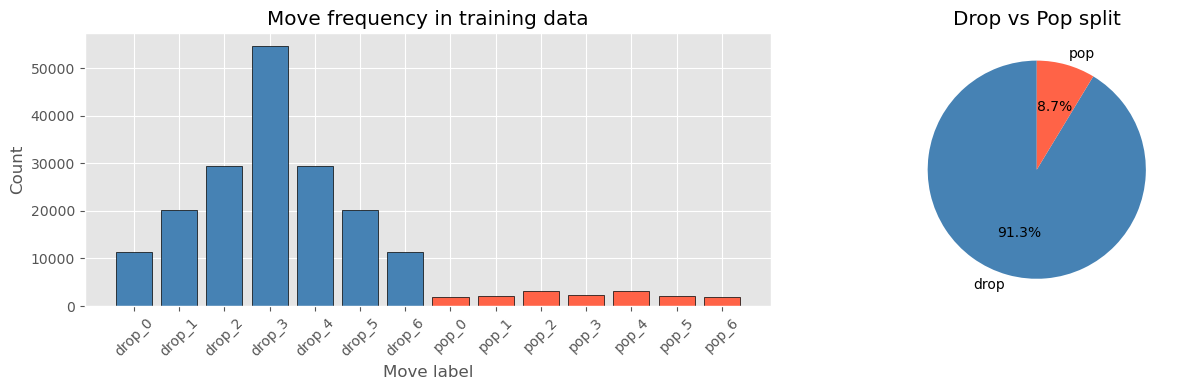

Drop moves: 176330 (91.3%)   Pop moves: 16728 (8.7%)


In [65]:
move_counts = df[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Move frequency
colors = ['steelblue' if m.startswith('drop') else 'tomato' for m in move_counts.index]
axes[0].bar(move_counts.index, move_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Move label')
axes[0].set_ylabel('Count')
axes[0].set_title('Move frequency in training data')
axes[0].tick_params(axis='x', rotation=45)

# Drop vs pop split
n_drop = sum(1 for m in df[TARGET] if m.startswith('drop'))
n_pop  = len(df) - n_drop
axes[1].pie([n_drop, n_pop], labels=['drop', 'pop'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Drop vs Pop split')

plt.tight_layout()
plt.show()

print(f'Drop moves: {n_drop} ({n_drop/len(df):.1%})   Pop moves: {n_pop} ({n_pop/len(df):.1%})')

## 3. ID3 Classifier — Training & Evaluation

Two ID3 trees are trained per version:

- **ID3 (features)** — all engineered features (`threats`, `phase`, `center`, etc.) plus raw cells
- **ID3 Raw** — raw cell occupancy values and `current_player` only; no hand-crafted features

Both use the same `ID3Classifier` from `src/decision_tree/id3/learner.py`.
Depth and oversampling factors come from `MODEL_CONFIGS` for the active version.

Proven positions (positions where the oracle found a forced win/loss) are
oversampled during training so the tree sees enough decisive examples.


## 3.1 Methodological note — train/test split leakage

The original split code

```python
df_train = df.sample(frac=0.8, random_state=42).reset_index(drop=True)
df_test  = df.drop(df_train.index).reset_index(drop=True)
```

contains a subtle bug: `reset_index(drop=True)` overwrites the sampled indices,
so `drop(df_train.index)` removes the **first 80 % of rows by position** rather
than the sampled rows. The result is that `df_train` and `df_test` share most rows.

To measure generalisation honestly we evaluate under **three splits**:

| Split | What it is | What it tests |
|---|---|---|
| **BUGGY** | the original broken split | how inflated the originally-reported accuracy was |
| **RANDOM** | correct row-level 80/20 | row-level generalisation (still affected by mirrored duplicate rows) |
| **GROUPED** | unique board states split 80/20, rows assigned accordingly | true state-level generalisation — no board state appears in both train and test |

**GROUPED is the canonical split** used for the feature sweep and all downstream analysis.


In [66]:
# ── Safety guard: re-read saved results if toggle cell wasn't re-run ────────
if _saved_accuracy is None and _acc_path.exists():
    with open(_acc_path) as _f:
        _saved_accuracy = _json.load(_f)
    print(f'[guard] Loaded pre-saved accuracy results for {ACTIVE_MODEL} — re-run toggle cell to suppress this.')
if _saved_sweep is None and _sweep_path.exists():
    with open(_sweep_path) as _f:
        _saved_sweep = _json.load(_f)
    print(f'[guard] Loaded pre-saved sweep results for {ACTIVE_MODEL} — re-run toggle cell to suppress this.')
if _saved_winrate is None and _winrate_path.exists():
    with open(_winrate_path) as _f:
        _saved_winrate = _json.load(_f)
    print(f'[guard] Loaded pre-saved win-rate results for {ACTIVE_MODEL} — re-run toggle cell to suppress this.')

OVERSAMPLE_FACTOR = 4

# Raw model: cell features only — no engineered columns — compensated by greater depth
RAW_FEAT_EXCLUDE = {'threats_me', 'threats_opp', 'center_me', 'center_opp',
                    'phase', 'can_win', 'opp_wins_next'}
# FEAT_DEPTH and RAW_DEPTH come from the model toggle cell above
RAW_FEATURE_COLS = [c for c in FEATURE_COLS if c not in RAW_FEAT_EXCLUDE]

_need_data_prep = _saved_accuracy is None or _saved_sweep is None
if _need_data_prep:
    # Convert integer features to string for ID3Classifier
    df_str = df.copy()
    for col in FEATURE_COLS:
        df_str[col] = df_str[col].astype(str)
    
    # Filter can_win=1 — _forced_move handles those during play for both models
    if FILTER_CAN_WIN:
        df_str_train = df_str[df_str["can_win"].astype(str) != "1"].reset_index(drop=True)
        print(f"Filtered out {len(df_str) - len(df_str_train):,} can_win=1 positions "
              f"({(len(df_str) - len(df_str_train))/len(df_str):.1%} of dataset)")
    else:
        df_str_train = df_str.reset_index(drop=True)
        print("can_win=1 filter not applied for this version")
    print()
    
    import numpy as np
    
    # (1) BUGGY — original split with reset_index bug
    df_train_buggy = df_str_train.sample(frac=0.8, random_state=42).reset_index(drop=True)
    df_test_buggy  = df_str_train.drop(df_train_buggy.index).reset_index(drop=True)
    
    # (2) RANDOM — correct row-level 80/20
    df_train_random = df_str_train.sample(frac=0.8, random_state=42)
    df_test_random  = df_str_train.drop(df_train_random.index)
    
    # (3) GROUPED — state-aware: no board state appears in both train and test
    _rng = np.random.default_rng(seed=42)
    _unique_states  = sorted(set(map(tuple, df_str_train[FEATURE_COLS].values)))
    _rng.shuffle(_unique_states)
    _n_train_states = int(0.8 * len(_unique_states))
    _train_state_set = set(_unique_states[:_n_train_states])
    _sig = df_str_train[FEATURE_COLS].apply(tuple, axis=1)
    df_train_grouped = df_str_train[ _sig.isin(_train_state_set)].reset_index(drop=True)
    df_test_grouped  = df_str_train[~_sig.isin(_train_state_set)].reset_index(drop=True)
    
    SPLIT_PAIRS = [
        ('BUGGY',   df_train_buggy,   df_test_buggy),
        ('RANDOM',  df_train_random,  df_test_random),
        ('GROUPED', df_train_grouped, df_test_grouped),
    ]
    
    def _state_overlap(d_train, d_test):
        train_sigs = set(map(tuple, d_train[FEATURE_COLS].values))
        test_sigs  = list(map(tuple, d_test[FEATURE_COLS].values))
        return sum(1 for s in test_sigs if s in train_sigs) / len(test_sigs)
    
    ov = {name: _state_overlap(d_tr, d_te) for name, d_tr, d_te in SPLIT_PAIRS}
else:
    df_train_grouped = df_test_grouped = None
    SPLIT_PAIRS = [(n, None, None) for n in ("BUGGY", "RANDOM", "GROUPED")]
    ov = {n: _saved_accuracy["splits"][n]["overlap"] for n in ("BUGGY", "RANDOM", "GROUPED")}
    print(f"All results pre-saved — skipping data prep ({ACTIVE_MODEL}).")


def _train_and_eval(d_tr, d_te, feature_cols, max_depth, oversample=OVERSAMPLE_FACTOR):
    proven = d_tr[d_tr["is_proven"].astype(str) == "1"]
    d_aug  = pd.concat([d_tr] + [proven] * oversample, ignore_index=True)
    clf    = ID3Classifier(max_depth=max_depth)
    t0     = time.perf_counter()
    clf.fit(d_aug[feature_cols + [TARGET]], target=TARGET)
    elapsed = time.perf_counter() - t0
    return clf, clf.score(d_tr[feature_cols + [TARGET]], target=TARGET), \
               clf.score(d_te[feature_cols + [TARGET]], target=TARGET), elapsed

def _tactical_breakdown(clf, d_test, feature_cols):
    preds   = clf.predict(d_test[feature_cols])
    correct = (preds == d_test[TARGET].astype(str))
    result  = {}
    opp_mask = d_test["opp_wins_next"].astype(str) == "1"
    if opp_mask.sum() > 0:
        result['opp_wins_next'] = {'n': int(opp_mask.sum()), 'accuracy': float(correct[opp_mask].mean())}
    pop_mask = d_test[TARGET].str.startswith("pop")
    if pop_mask.sum() > 0:
        result['pop_moves'] = {'n': int(pop_mask.sum()), 'accuracy': float(correct[pop_mask].mean())}
    return result

if _saved_accuracy is not None:
    # ── Load pre-saved results ────────────────────────────────────────────────
    print(f"Pre-saved accuracy results loaded for {ACTIVE_MODEL} ({VERSION}) — skipping retraining.")
    _s = _saved_accuracy['splits']
    _feat_acc = {k: (_s[k]['feat']['train_acc'], _s[k]['feat']['test_acc'], _s[k]['feat']['time'])
                 for k in ('BUGGY', 'RANDOM', 'GROUPED')}
    _raw_acc  = {k: (_s[k]['raw']['train_acc'],  _s[k]['raw']['test_acc'],  _s[k]['raw']['time'])
                 for k in ('BUGGY', 'RANDOM', 'GROUPED')}
    _tactical     = _saved_accuracy.get('tactical', {})
    clf_full = clf_full_raw = None
else:
    # ── Compute from scratch ──────────────────────────────────────────────────
    print(f"Training ID3 — feat (depth={FEAT_DEPTH}) and raw (depth={RAW_DEPTH}) — under each split ...")
    print()
    _feat_acc = {}
    _raw_acc  = {}
    _clfs     = {}
    for split_name, d_tr, d_te in SPLIT_PAIRS:
        print(f"  {split_name:<7}  ({len(d_tr):>6,} train / {len(d_te):>6,} test)")
        clf_f, f_tr, f_te, t_f = _train_and_eval(d_tr, d_te, FEATURE_COLS,     max_depth=FEAT_DEPTH)
        clf_r, r_tr, r_te, t_r = _train_and_eval(d_tr, d_te, RAW_FEATURE_COLS, max_depth=RAW_DEPTH, oversample=RAW_OVERSAMPLE)
        print(f"    feat d={FEAT_DEPTH} : train={f_tr:.3f}  test={f_te:.3f}  ({t_f:.1f}s)")
        print(f"    raw  d={RAW_DEPTH} : train={r_tr:.3f}  test={r_te:.3f}  ({t_r:.1f}s)")
        _feat_acc[split_name] = (f_tr, f_te, t_f)
        _raw_acc[split_name]  = (r_tr, r_te, t_r)
        _clfs[split_name]     = (clf_f, clf_r)
        print()

    clf_full     = _clfs['GROUPED'][0]
    clf_full_raw = _clfs['GROUPED'][1]
    _tactical    = {
        'feat': _tactical_breakdown(clf_full,     df_test_grouped, FEATURE_COLS),
        'raw':  _tactical_breakdown(clf_full_raw, df_test_grouped, RAW_FEATURE_COLS),
    }

    # ── Save ──────────────────────────────────────────────────────────────────
    _acc_data = {
        'version': VERSION,
        'splits': {
            split_name: {
                'train_rows': len(d_tr), 'test_rows': len(d_te), 'overlap': ov[split_name],
                'feat': {'train_acc': _feat_acc[split_name][0], 'test_acc': _feat_acc[split_name][1],
                         'time':      _feat_acc[split_name][2]},
                'raw':  {'train_acc': _raw_acc[split_name][0],  'test_acc': _raw_acc[split_name][1],
                         'time':      _raw_acc[split_name][2]},
            }
            for split_name, d_tr, d_te in SPLIT_PAIRS
        },
        'tactical': _tactical,
    }
    _acc_data['feature_importance'] = {
        'feat': clf_full.get_feature_importance(),
        'raw':  clf_full_raw.get_feature_importance(),
    }
    _acc_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_acc_path, 'w') as _f:
        _json.dump(_acc_data, _f, indent=2)
    print(f'Accuracy results saved → {_acc_path}')

# ── Comparison table ──────────────────────────────────────────────────────────
print()
_H = (f"{'Split':<10} {'rows(tr/te)':>15} {'overlap':>8}  "
      f"{'feat_train':>10} {'feat_test':>9} {'Δ':>6}  "
      f"{'raw_train':>9} {'raw_test':>8} {'Δ':>6}")
print("=" * len(_H))
print(_H)
print("-" * len(_H))
for split_name, d_tr, d_te in SPLIT_PAIRS:
    f_tr, f_te, _ = _feat_acc[split_name]
    r_tr, r_te, _ = _raw_acc[split_name]
    _tr_n = len(d_tr) if d_tr is not None else _saved_accuracy["splits"][split_name]["train_rows"]
    _te_n = len(d_te) if d_te is not None else _saved_accuracy["splits"][split_name]["test_rows"]
    print(f"{split_name:<10} {_tr_n:>7,}/{_te_n:<7,} {ov[split_name]:>8.1%}  "
          f"{f_tr:>10.3f} {f_te:>9.3f} {f_tr-f_te:>+6.3f}  "
          f"{r_tr:>9.3f} {r_te:>8.3f} {r_tr-r_te:>+6.3f}")
print("=" * len(_H))

f_g_tr, f_g_te, _ = _feat_acc['GROUPED']
r_g_tr, r_g_te, _ = _raw_acc['GROUPED']
print()
print("Interpretation (GROUPED split — no data leakage):")
print(f"  feat  generalisation gap: {f_g_tr - f_g_te:+.3f}  (train={f_g_tr:.3f}  test={f_g_te:.3f})")
print(f"  raw   generalisation gap: {r_g_tr - r_g_te:+.3f}  (train={r_g_tr:.3f}  test={r_g_te:.3f})")
print()
print("→ GROUPED is the canonical split for downstream analysis.")

# ── Set canonical variables for downstream cells ──────────────────────────────
if _need_data_prep:
    df_train     = df_train_grouped
    df_test      = df_test_grouped
    proven       = df_train[df_train["is_proven"].astype(str) == "1"]
    df_train_aug = pd.concat([df_train] + [proven] * OVERSAMPLE_FACTOR, ignore_index=True)
else:
    df_train = df_test = df_train_aug = None

# ── Tactical breakdown ────────────────────────────────────────────────────────
for variant_label, variant_key in [('ID3 (features)', 'feat'), ('ID3 Raw', 'raw')]:
    tac = _tactical.get(variant_key, {})
    if not tac:
        continue
    suffix = '' if clf_full is not None else '  (pre-saved)'
    print(f"\nTactical accuracy — {variant_label}:")
    if 'opp_wins_next' in tac:
        v = tac['opp_wins_next']
        print(f"  opp_wins_next=1  (n={v['n']:4d}): {v['accuracy']:.3f}{suffix}")
    if 'pop_moves' in tac:
        v = tac['pop_moves']
        print(f"  pop moves        (n={v['n']:4d}): {v['accuracy']:.3f}{suffix}")

All results pre-saved — skipping data prep (v3).
Pre-saved accuracy results loaded for v3 (v3_5000games_tiered) — skipping retraining.

Split          rows(tr/te)  overlap  feat_train feat_test      Δ  raw_train raw_test      Δ
-------------------------------------------------------------------------------------------
BUGGY      154,446/38,612     94.5%       0.850     0.812 +0.038      0.911    0.878 +0.032
RANDOM     154,446/38,612     78.2%       0.850     0.709 +0.140      0.911    0.750 +0.161
GROUPED    143,154/49,904      0.0%       0.855     0.585 +0.270      0.904    0.495 +0.409

Interpretation (GROUPED split — no data leakage):
  feat  generalisation gap: +0.270  (train=0.855  test=0.585)
  raw   generalisation gap: +0.409  (train=0.904  test=0.495)

→ GROUPED is the canonical split for downstream analysis.

Tactical accuracy — ID3 (features):
  opp_wins_next=1  (n=6046): 0.256  (pre-saved)
  pop moves        (n=3208): 0.287  (pre-saved)

Tactical accuracy — ID3 Raw:
  opp_w

In [67]:
if clf_full is not None:
    # Fresh computation — importances come straight from the trained classifiers
    _importances = {
        'feat': clf_full.get_feature_importance(),
        'raw':  clf_full_raw.get_feature_importance(),
    }
elif _saved_accuracy and 'feature_importance' in _saved_accuracy:
    # Already stored in the JSON — load directly
    _importances = _saved_accuracy['feature_importance']
else:
    # Saved file predates this feature — retrain GROUPED models only and update the file
    print("Feature importance not in saved file — retraining GROUPED models (one-time cost)...")
    _proven_g = df_train[df_train["is_proven"].astype(str) == "1"]
    _aug_g    = pd.concat([df_train] + [_proven_g] * OVERSAMPLE_FACTOR, ignore_index=True)
    _clf_f = ID3Classifier(max_depth=FEAT_DEPTH)
    _clf_f.fit(_aug_g[FEATURE_COLS + [TARGET]], target=TARGET)
    _clf_r = ID3Classifier(max_depth=RAW_DEPTH)
    _clf_r.fit(_aug_g[RAW_FEATURE_COLS + [TARGET]], target=TARGET)
    _importances = {
        'feat': _clf_f.get_feature_importance(),
        'raw':  _clf_r.get_feature_importance(),
    }
    _saved_accuracy['feature_importance'] = _importances
    with open(_acc_path, 'w') as _f:
        _json.dump(_saved_accuracy, _f, indent=2)
    print(f'Saved file updated with feature importance \u2192 {_acc_path}')



## 4. Feature Sweep

Features are ranked by their **information gain** on the GROUPED training set.
We then train separate ID3 trees using only the top-K features and measure
train and test accuracy as K increases.

The curve shows:
1. How model capacity grows with the number of features available
2. The true marginal value of each additional feature for generalisation
   (GROUPED ensures there is no leakage inflating the test numbers)


Pre-saved sweep results loaded for v3 — skipping IG computation.
Top 10 features by IG — ID3 (features):
   1. center_me           IG = 0.3358
   2. phase               IG = 0.2637
   3. center_opp          IG = 0.2589
   4. cell_2_3            IG = 0.1750
   5. cell_3_3            IG = 0.1708
   6. threats_me          IG = 0.1493
   7. threats_opp         IG = 0.1452
   8. cell_4_3            IG = 0.1409
   9. cell_1_4            IG = 0.1128
  10. cell_1_2            IG = 0.1116

Top 10 features by IG — ID3 Raw:
   1. cell_2_3            IG = 0.1750
   2. cell_3_3            IG = 0.1708
   3. cell_4_3            IG = 0.1409
   4. cell_1_4            IG = 0.1128
   5. cell_1_2            IG = 0.1116
   6. cell_5_3            IG = 0.1066
   7. cell_2_4            IG = 0.1044
   8. cell_2_2            IG = 0.1040
   9. cell_1_3            IG = 0.0985
  10. cell_0_5            IG = 0.0936


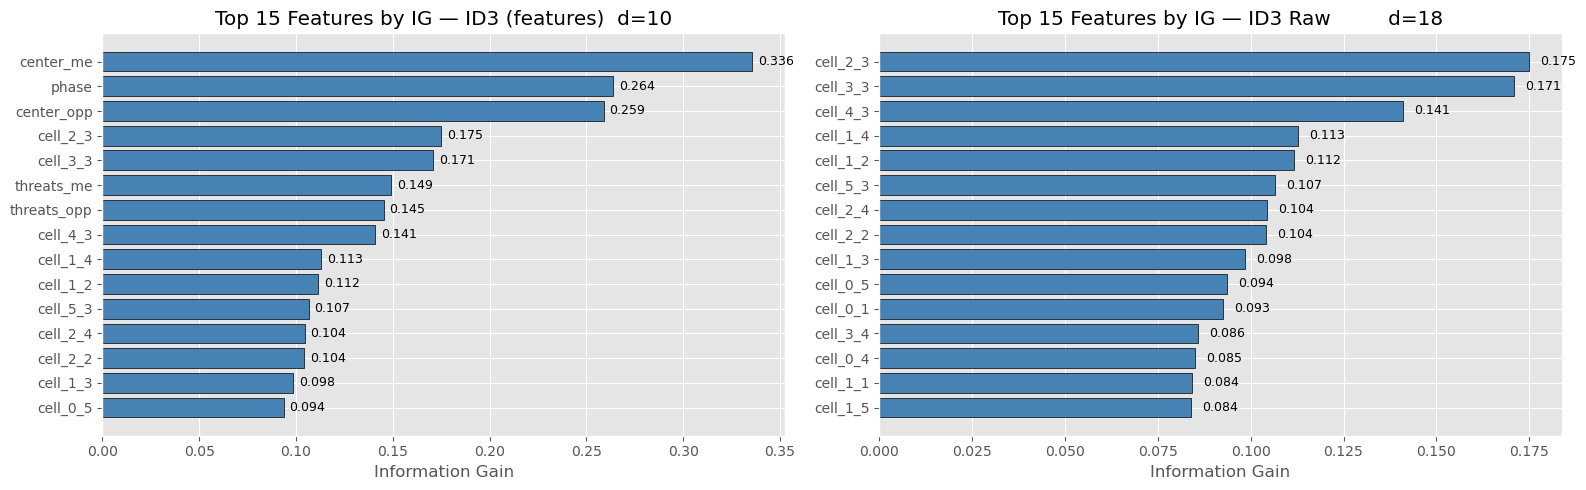

In [68]:
if _saved_sweep is not None:
    print(f"Pre-saved sweep results loaded for {ACTIVE_MODEL} — skipping IG computation.")
    ranked_feat    = _saved_sweep['feat']['ranked_features']
    ig_scores_feat = _saved_sweep['feat']['ig_scores']
    ranked_raw     = _saved_sweep['raw']['ranked_features']
    ig_scores_raw  = _saved_sweep['raw']['ig_scores']
else:
    _ranker = ID3Classifier()
    ig_scores_feat = {f: _ranker.information_gain(df_train, f, TARGET) for f in FEATURE_COLS}
    ranked_feat    = sorted(ig_scores_feat, key=ig_scores_feat.get, reverse=True)
    ig_scores_raw  = {f: _ranker.information_gain(df_train, f, TARGET) for f in RAW_FEATURE_COLS}
    ranked_raw     = sorted(ig_scores_raw,  key=ig_scores_raw.get,  reverse=True)

ranked_features = ranked_feat  # backward-compat alias used by downstream cells

print('Top 10 features by IG — ID3 (features):')
for i, f in enumerate(ranked_feat[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores_feat[f]:.4f}')

print()
print('Top 10 features by IG — ID3 Raw:')
for i, f in enumerate(ranked_raw[:10], 1):
    print(f'  {i:2d}. {f:<18}  IG = {ig_scores_raw[f]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_n = 15
for ax, ranked, ig_scores, title in [
    (axes[0], ranked_feat, ig_scores_feat, f'ID3 (features)  d={FEAT_DEPTH}'),
    (axes[1], ranked_raw,  ig_scores_raw,  f'ID3 Raw         d={RAW_DEPTH}'),
]:
    feats  = ranked[:top_n]
    scores = [ig_scores[f] for f in feats]
    bars = ax.barh(feats[::-1], scores[::-1], color='steelblue', edgecolor='black')
    for bar, val in zip(bars, scores[::-1]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlabel('Information Gain')
    ax.set_title(f'Top {top_n} Features by IG — {title}')
plt.tight_layout()
plt.show()

In [69]:
K_VALUES_FEAT = [1, 3, 5, 10, 15, 20, 30, len(FEATURE_COLS)]
K_VALUES_RAW  = [1, 3, 5, 10, 15, 20, 30, len(RAW_FEATURE_COLS)]

if _saved_sweep is not None:
    print(f"Pre-saved sweep results loaded for {ACTIVE_MODEL} — skipping sweep computation.")
    sweep_df_feat = pd.DataFrame(_saved_sweep['feat']['sweep'])
    sweep_df_raw  = pd.DataFrame(_saved_sweep['raw']['sweep'])
else:
    def _run_sweep(ranked, k_values, depth, label):
        results = []
        print(f"Feature sweep — {label} (depth={depth})")
        for k in k_values:
            cols  = ranked[:k] + [TARGET]
            clf_k = ID3Classifier(max_depth=depth)
            clf_k.fit(df_train[cols], target=TARGET)
            tr = clf_k.score(df_train[cols], target=TARGET)
            te = clf_k.score(df_test[cols],  target=TARGET)
            results.append({'K': k, 'train': tr, 'test': te})
            print(f'  K={k:3d}  train={tr:.3f}  test={te:.3f}')
        return results

    sweep_results_feat = _run_sweep(ranked_feat, K_VALUES_FEAT, FEAT_DEPTH, 'ID3 (features)')
    print()
    sweep_results_raw  = _run_sweep(ranked_raw,  K_VALUES_RAW,  RAW_DEPTH,  'ID3 Raw')

    sweep_df_feat = pd.DataFrame(sweep_results_feat)
    sweep_df_raw  = pd.DataFrame(sweep_results_raw)

    _sweep_data = {
        'version':    VERSION,
        'feat_depth': FEAT_DEPTH,
        'raw_depth':  RAW_DEPTH,
        'feat': {
            'ranked_features': ranked_feat,
            'ig_scores':       ig_scores_feat,
            'k_values':        K_VALUES_FEAT,
            'sweep':           sweep_results_feat,
        },
        'raw': {
            'ranked_features': ranked_raw,
            'ig_scores':       ig_scores_raw,
            'k_values':        K_VALUES_RAW,
            'sweep':           sweep_results_raw,
        },
    }
    _sweep_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_sweep_path, 'w') as _f:
        _json.dump(_sweep_data, _f, indent=2)
    print(f'\nSweep results saved → {_sweep_path}')

sweep_df = sweep_df_feat  # backward-compat alias

Pre-saved sweep results loaded for v3 — skipping sweep computation.


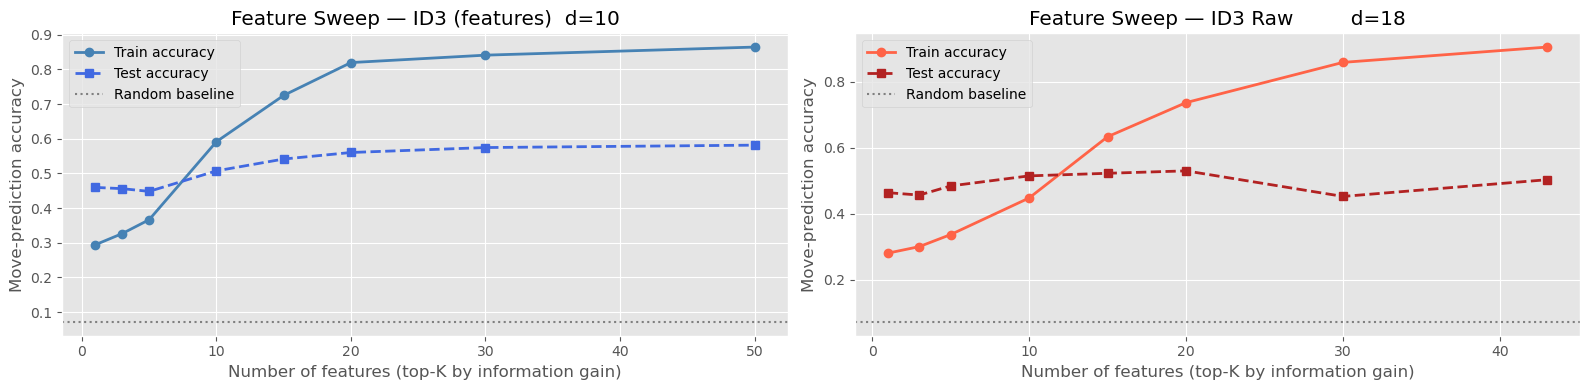

In [70]:
_random_baseline = 1 / df[TARGET].nunique()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, sdf, title, c_tr, c_te in [
    (axes[0], sweep_df_feat, f'ID3 (features)  d={FEAT_DEPTH}', 'steelblue', 'royalblue'),
    (axes[1], sweep_df_raw,  f'ID3 Raw         d={RAW_DEPTH}',  'tomato',    'firebrick'),
]:
    ax.plot(sdf['K'], sdf['train'], 'o-',  label='Train accuracy', color=c_tr, linewidth=2)
    ax.plot(sdf['K'], sdf['test'],  's--', label='Test accuracy',  color=c_te, linewidth=2)
    ax.axhline(_random_baseline, color='gray', linestyle=':', label='Random baseline')
    ax.set_xlabel('Number of features (top-K by information gain)')
    ax.set_ylabel('Move-prediction accuracy')
    ax.set_title(f'Feature Sweep — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

### Feature-sweep discussion

Three consistent patterns appear across versions:

1. **Train accuracy grows with K** — the tree has capacity to memorise the training set.
2. **Test accuracy plateaus early** — most of the generalisable signal is concentrated
   in the top ~15 features (centre control, phase, central column cells, opponent threats).
   Features beyond that point add almost nothing for unseen positions.
3. **At very low K, test accuracy can exceed train accuracy.** This is an artefact of
   proven-position oversampling: the train distribution is artificially inflated, while
   the test set reflects the natural distribution. A shallow tree that learns one robust
   rule (e.g. split on `center_me`) fits the natural test distribution slightly better
   than the skewed training one. The effect disappears as K grows and the tree begins
   memorising specific board configurations.

The train/test gap at full K reflects a clear **high-variance** regime: the tree
memorises training positions but only a fraction of that signal transfers to unseen
states. The GROUPED test accuracy is nonetheless well above trivial baselines
(random over 14 classes ≈ 7 %, always-`drop_3` ≈ 28 %).


## 5. Win-Rate Evaluation

The trained trees are evaluated against two MCTS engine families at multiple
iteration counts, playing 100 games per configuration with alternating sides.

| Engine | Notes |
|---|---|
| **FlatNumbaMCTS** | Standard MCTS, no proof propagation |
| **FlatNumbaSolverMCTS** | MCTS-Solver — exits early when a position is proven |

Moves are selected through the full `ID3Agent` / `ID3AgentRaw` wrappers, which
apply the `_forced_move` rule layer (immediate win / block) before consulting
the tree.

Four tree variants are tested: featured and raw, each in wrapped and pure (no
`_forced_move`) mode. The pure variant isolates the tree's own decision quality.


In [71]:
import pickle, gc

import ctypes as _ct
# Free memory from earlier cells before heavy training
_gns = globals()
for _v in ['df_str', 'df_str_train', 'df_train', 'df_test', 'df_train_aug',
           'clf_full', 'clf_k', 'sweep_df', 'sweep_results', '_ranker', 'ig_scores', 'ranked_features']:
    _gns.pop(_v, None)
del _gns
gc.collect()
try: _ct.cdll.LoadLibrary('libc.so.6').malloc_trim(0)
except: pass

PICKLE_PATH     = Path(f'../data/generated/{VERSION}/id3_model.pkl')
PICKLE_RAW_PATH = Path(f'../data/generated/{VERSION}/id3_model_raw.pkl')

_EXCLUDE_RAW = {'best_move', 'is_proven', 'threats_me', 'threats_opp',
                'center_me', 'center_opp', 'phase', 'can_win', 'opp_wins_next'}
# RAW_DEPTH comes from the model toggle cell above

# ── ID3 with engineered features ─────────────────────────────────────────────
if PICKLE_PATH.exists():
    print(f'Loading clf_game from {PICKLE_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_PATH, 'rb') as f:
        clf_game = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print(f'Training clf_game on full dataset (features, depth={FEAT_DEPTH}, 4x proven oversampling)...')
    if FILTER_CAN_WIN:
        _df = df[df['can_win'] != 1].reset_index(drop=True)
        print(f'  After can_win=1 filter: {len(_df):,} rows')
    else:
        _df = df.copy()
    _feat_cols = [c for c in _df.columns if c not in ('best_move', 'is_proven')]
    if 'is_proven' in _df.columns:
        _proven = _df[_df['is_proven'] == 1]
        _df = pd.concat([_df] + [_proven] * 4, ignore_index=True)
        del _proven
    for c in _feat_cols: _df[c] = _df[c].astype(str)
    _df['best_move'] = _df['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game = ID3Classifier(max_depth=FEAT_DEPTH)
    clf_game.fit(_df[_feat_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df; gc.collect()
    try: _ct.cdll.LoadLibrary('libc.so.6').malloc_trim(0)
    except: pass
    PICKLE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_PATH, 'wb') as f: pickle.dump(clf_game, f)
    print(f'  Saved to {PICKLE_PATH}')

# ── ID3 Raw (raw cells only, proven oversampling) ─────────────────────────────
if PICKLE_RAW_PATH.exists():
    print(f'\nLoading clf_game_raw from {PICKLE_RAW_PATH} ...')
    t0 = time.perf_counter()
    with open(PICKLE_RAW_PATH, 'rb') as f:
        clf_game_raw = pickle.load(f)
    print(f'  Loaded in {time.perf_counter()-t0:.2f}s')
else:
    print(f'\nTraining clf_game_raw (raw cells, depth={RAW_DEPTH}, {RAW_OVERSAMPLE}x proven)...')
    if FILTER_CAN_WIN:
        _df_raw = df[df['can_win'] != 1].reset_index(drop=True)
        print(f'  After can_win=1 filter: {len(_df_raw):,} rows')
    else:
        _df_raw = df.copy()
    _raw_cols = [c for c in _df_raw.columns if c not in _EXCLUDE_RAW]
    if 'is_proven' in _df_raw.columns:
        _proven = _df_raw[_df_raw['is_proven'] == 1]
        _df_raw = pd.concat([_df_raw] + [_proven] * RAW_OVERSAMPLE, ignore_index=True)
        del _proven
    for c in _raw_cols: _df_raw[c] = _df_raw[c].astype(str)
    _df_raw['best_move'] = _df_raw['best_move'].astype(str)
    t0 = time.perf_counter()
    clf_game_raw = ID3Classifier(max_depth=RAW_DEPTH)
    clf_game_raw.fit(_df_raw[_raw_cols + ['best_move']], target='best_move')
    print(f'  Trained in {time.perf_counter()-t0:.1f}s')
    del _df_raw; gc.collect()
    PICKLE_RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(PICKLE_RAW_PATH, 'wb') as f: pickle.dump(clf_game_raw, f)
    print(f'  Saved to {PICKLE_RAW_PATH}')


Loading clf_game from ../data/generated/v3_5000games_tiered/id3_model.pkl ...
  Loaded in 0.10s

Loading clf_game_raw from ../data/generated/v3_5000games_tiered/id3_model_raw.pkl ...
  Loaded in 0.23s


In [72]:
from src.mcts.optimized.numba_mcts import warmup, FlatNumbaMCTS
from src.mcts.optimized.numba_solver import FlatNumbaSolverMCTS

print('Warming up Numba JIT (one-time cost, ~2–5 s) ...')
t0 = time.perf_counter()
warmup()   # covers FlatNumbaMCTS, NumbaMCTS, FlatNumbaSolverMCTS and all kernels
print(f'Warmup done in {time.perf_counter() - t0:.1f} s')

Warming up Numba JIT (one-time cost, ~2–5 s) ...
Warmup done in 0.0 s


In [73]:
import types
from src.decision_tree.id3_agent import ID3Agent
from src.decision_tree.id3_agent_raw import ID3AgentRaw

def _make_tree_agent(clf, raw=False):
    """Wrap classifier in the agent class — includes _forced_move."""
    agent = (ID3AgentRaw() if raw else ID3Agent())
    agent._classifier = clf
    return agent

def _make_tree_agent_pure(clf, raw=False):
    """Wrap classifier without _forced_move — pure tree prediction only.

    Matches exactly what the accuracy test measures: the tree's own prediction
    with no immediate-win/block rule applied beforehand.
    """
    agent = (ID3AgentRaw() if raw else ID3Agent())
    agent._classifier = clf

    if raw:
        def _run(self, board, iterations=0):
            row = pd.Series({k: str(v) for k, v in board.to_feature_dict().items()})
            return self._parse_move(self._classifier.predict_one(row), board.legal_moves())
    else:
        def _run(self, board, iterations=0):
            features = extended_features(board)
            row = pd.Series({k: str(v) for k, v in features.items() if k != 'is_proven'})
            return self._parse_move(self._classifier.predict_one(row), board.legal_moves())

    agent.run = types.MethodType(_run, agent)
    return agent

def play_one_game(tree_agent, mcts_agent, tree_plays_as, mcts_iterations, max_moves=120):
    """Play one game. Returns +1 (tree wins), -1 (tree loses), 0 (draw)."""
    board = PopOutBoard()
    for _ in range(max_moves):
        legal = board.legal_moves()
        if not legal:
            return 0
        mover = board.current_player
        if mover == tree_plays_as:
            move = tree_agent.run(board)
        else:
            move = mcts_agent.run(board, iterations=mcts_iterations)
        board.apply_move(move)
        winner = evaluate_after_move(board, mover=mover)
        if winner != 0:
            return 1 if winner == tree_plays_as else -1
    return 0

In [74]:
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor, as_completed
from src.decision_tree.game_eval import _init_eval_worker, eval_config

EVAL_GAMES = 100
N_WORKERS  = 20

CONFIGS = {
    'FlatNumbaMCTS':       [100, 500, 1_000, 5_000, 10_000],
    'FlatNumbaSolverMCTS': [1_000, 5_000, 10_000, 50_000, 100_000],
}

TREE_MODELS = {
    'ID3 (features)':      _make_tree_agent(     clf_game,     raw=False),
    'ID3 Raw':             _make_tree_agent(     clf_game_raw, raw=True),
    'ID3 (features) pure': _make_tree_agent_pure(clf_game,     raw=False),
    'ID3 Raw pure':        _make_tree_agent_pure(clf_game_raw, raw=True),
}

# Spec passed to worker: (is_raw, is_pure) — no large objects cross the boundary
_MODEL_SPEC = {
    'ID3 (features)':      (False, False),
    'ID3 Raw':             (True,  False),
    'ID3 (features) pure': (False, True),
    'ID3 Raw pure':        (True,  True),
}

if _saved_winrate is not None:
    # ── Load pre-saved results ────────────────────────────────────────────────
    eval_results = {}
    for model_name, engines in _saved_winrate['results'].items():
        for engine_name, iters_dict in engines.items():
            for iters_str, wld in iters_dict.items():
                eval_results[(model_name, engine_name, int(iters_str))] = tuple(wld)
    print(f"Pre-saved win-rate results loaded for {ACTIVE_MODEL} ({VERSION}) — skipping game evaluation.\n")
    for model_name in TREE_MODELS:
        print(f'\n── {model_name} ──')
        for engine_name, iter_list in CONFIGS.items():
            for iters in iter_list:
                w, l, d = eval_results[(model_name, engine_name, iters)]
                print(f'  {engine_name:22s}  {iters:7,d} iter  ->  {w/EVAL_GAMES:5.1%}  '
                      f'({w}W / {l}L / {d}D)')
            print()
else:
    # ── Parallel evaluation ───────────────────────────────────────────────────
    _tasks = [
        (mn, en, it)
        for mn in TREE_MODELS
        for en, iter_list in CONFIGS.items()
        for it in iter_list
    ]
    print(f'Running {len(_tasks)} configs × {EVAL_GAMES} games on {N_WORKERS} workers ...\n')
    t0 = time.perf_counter()
    eval_results = {}

    with ProcessPoolExecutor(
        max_workers=N_WORKERS,
        initializer=_init_eval_worker,
        initargs=(str(PICKLE_PATH), str(PICKLE_RAW_PATH)),
        mp_context=_mp.get_context('spawn'),
    ) as _pool:
        _futures = {
            _pool.submit(
                eval_config,
                *_MODEL_SPEC[mn], en, it, EVAL_GAMES,
                abs(hash((mn, en, it))) % (2**31),
            ): (mn, en, it)
            for mn, en, it in _tasks
        }
        for _fut in as_completed(_futures):
            mn, en, it = _futures[_fut]
            w, l, d = _fut.result()
            eval_results[(mn, en, it)] = (w, l, d)
            print(f'{mn:<25}  {en:<22}  {it:>7,}  ->  {w/EVAL_GAMES:5.1%}  ({w}W/{l}L/{d}D)')

    print(f'\nTotal evaluation time: {time.perf_counter()-t0:.1f}s')

    _wr_data = {
        'version':    VERSION,
        'eval_games': EVAL_GAMES,
        'results': {
            model_name: {
                engine_name: {str(it): list(eval_results[(model_name, engine_name, it)])
                               for it in iter_list}
                for engine_name, iter_list in CONFIGS.items()
            }
            for model_name in TREE_MODELS
        }
    }
    _winrate_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_winrate_path, 'w') as _f:
        _json.dump(_wr_data, _f, indent=2)
    print(f'Win-rate results saved -> {_winrate_path}')


Pre-saved win-rate results loaded for v3 (v3_5000games_tiered) — skipping game evaluation.


── ID3 (features) ──
  FlatNumbaMCTS               100 iter  ->  91.0%  (91W / 9L / 0D)
  FlatNumbaMCTS               500 iter  ->  63.0%  (63W / 37L / 0D)
  FlatNumbaMCTS             1,000 iter  ->  56.0%  (56W / 44L / 0D)
  FlatNumbaMCTS             5,000 iter  ->  40.0%  (40W / 60L / 0D)
  FlatNumbaMCTS            10,000 iter  ->  39.0%  (39W / 61L / 0D)

  FlatNumbaSolverMCTS       1,000 iter  ->  49.0%  (49W / 51L / 0D)
  FlatNumbaSolverMCTS       5,000 iter  ->  40.0%  (40W / 59L / 1D)
  FlatNumbaSolverMCTS      10,000 iter  ->  36.0%  (36W / 64L / 0D)
  FlatNumbaSolverMCTS      50,000 iter  ->  52.0%  (52W / 48L / 0D)
  FlatNumbaSolverMCTS     100,000 iter  ->  50.0%  (50W / 50L / 0D)


── ID3 Raw ──
  FlatNumbaMCTS               100 iter  ->  92.0%  (92W / 8L / 0D)
  FlatNumbaMCTS               500 iter  ->  65.0%  (65W / 35L / 0D)
  FlatNumbaMCTS             1,000 iter  ->  47.0%  (47W

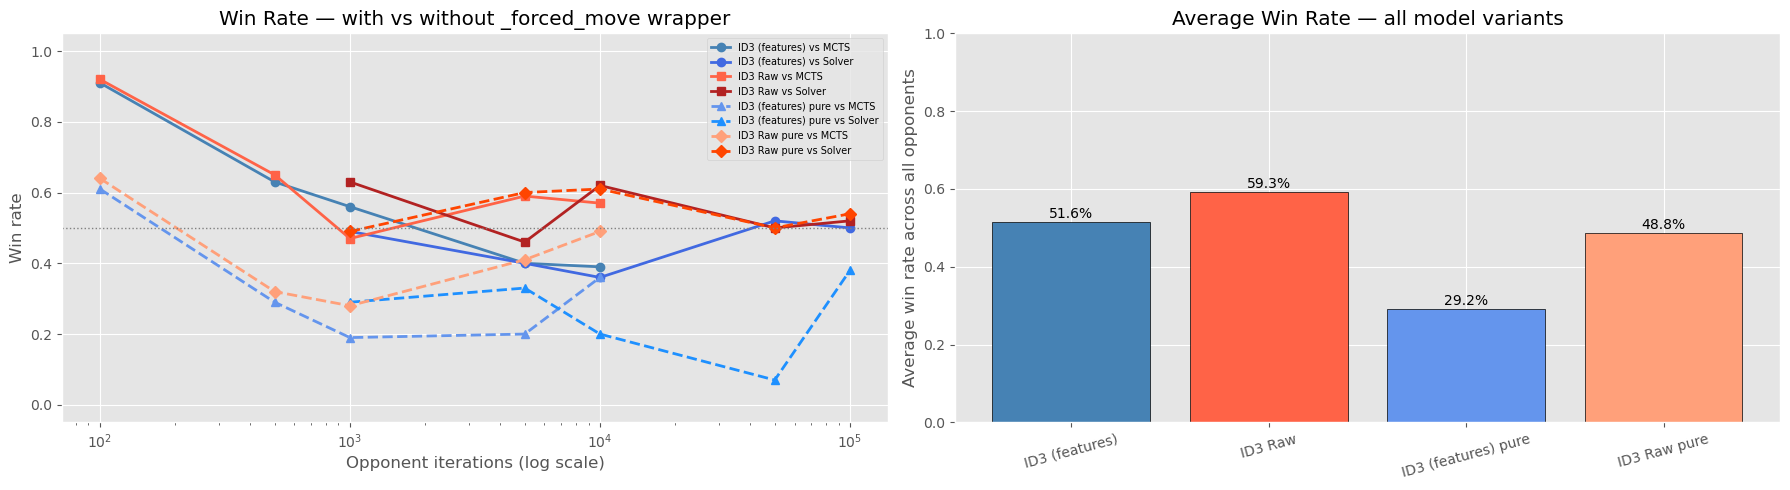


Model                      Opponent engine         Iterations     Win%     W     L     D
------------------------------------------------------------------------------
ID3 (features)             FlatNumbaMCTS                  100    91.0%    91     9     0
ID3 (features)             FlatNumbaMCTS                  500    63.0%    63    37     0
ID3 (features)             FlatNumbaMCTS                1,000    56.0%    56    44     0
ID3 (features)             FlatNumbaMCTS                5,000    40.0%    40    60     0
ID3 (features)             FlatNumbaMCTS               10,000    39.0%    39    61     0
ID3 (features)             FlatNumbaSolverMCTS          1,000    49.0%    49    51     0
ID3 (features)             FlatNumbaSolverMCTS          5,000    40.0%    40    59     1
ID3 (features)             FlatNumbaSolverMCTS         10,000    36.0%    36    64     0
ID3 (features)             FlatNumbaSolverMCTS         50,000    52.0%    52    48     0
ID3 (features)             Fla

In [75]:
ENGINE_SHORT = {'FlatNumbaMCTS': 'MCTS', 'FlatNumbaSolverMCTS': 'Solver'}

_MODEL_STYLE = {
    'ID3 (features)':      {'colors': {'FlatNumbaMCTS': 'steelblue',     'FlatNumbaSolverMCTS': 'royalblue'},   'marker': 'o', 'ls': '-'},
    'ID3 Raw':             {'colors': {'FlatNumbaMCTS': 'tomato',         'FlatNumbaSolverMCTS': 'firebrick'},   'marker': 's', 'ls': '-'},
    'ID3 (features) pure': {'colors': {'FlatNumbaMCTS': 'cornflowerblue', 'FlatNumbaSolverMCTS': 'dodgerblue'}, 'marker': '^', 'ls': '--'},
    'ID3 Raw pure':        {'colors': {'FlatNumbaMCTS': 'lightsalmon',    'FlatNumbaSolverMCTS': 'orangered'},   'marker': 'D', 'ls': '--'},
}
_BAR_COLORS = ['steelblue', 'tomato', 'cornflowerblue', 'lightsalmon']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for model_name in TREE_MODELS:
    style = _MODEL_STYLE[model_name]
    for engine_name, iter_list in CONFIGS.items():
        win_rates = [eval_results[(model_name, engine_name, it)][0] / EVAL_GAMES
                     for it in iter_list]
        axes[0].plot(iter_list, win_rates,
                     marker=style['marker'], linestyle=style['ls'],
                     color=style['colors'][engine_name], linewidth=2,
                     label=f'{model_name} vs {ENGINE_SHORT[engine_name]}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Opponent iterations (log scale)')
axes[0].set_ylabel('Win rate')
axes[0].set_title('Win Rate — with vs without _forced_move wrapper')
axes[0].set_ylim(-0.05, 1.05)
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1)
axes[0].legend(fontsize=7)

model_names = list(TREE_MODELS.keys())
avg_wr = [
    np.mean([eval_results[(m, eng, it)][0] / EVAL_GAMES
             for eng, iters in CONFIGS.items() for it in iters])
    for m in model_names
]
bars = axes[1].bar(model_names, avg_wr,
                   color=_BAR_COLORS[:len(model_names)], edgecolor='black')
for bar, v in zip(bars, avg_wr):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{v:.1%}', ha='center', fontsize=10)
axes[1].set_ylabel('Average win rate across all opponents')
axes[1].set_title('Average Win Rate — all model variants')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(f'\n{"Model":<25}  {"Opponent engine":<22}  {"Iterations":>10}  {"Win%":>7}  {"W":>4}  {"L":>4}  {"D":>4}')
print('-' * 78)
for model_name in TREE_MODELS:
    for engine_name, iter_list in CONFIGS.items():
        for it in iter_list:
            w, l, d = eval_results[(model_name, engine_name, it)]
            print(f'{model_name:<25}  {engine_name:<22}  {it:>10,}  '
                  f'{w/EVAL_GAMES:>7.1%}  {w:>4}  {l:>4}  {d:>4}')
    print()

## 6. Cross-Version Comparison

All four trained models are evaluated head-to-head against `FlatNumbaSolverMCTS`
at 1 000 and 10 000 iterations (50 games each, alternating sides).

| Version | Dataset | Raw oversampling | can_win filter |
|---|---|---|---|
| v1 | 3 000 games, 100 k iter oracle | 10× | No |
| v2 | 5 000 games, 100 k iter oracle | 10× | No |
| v3 | 5 000 games, tiered blunders | 10× | No |
| v4 | 75 000 games, tiered blunders | 4× | Yes (wrapper handles them) |


In [76]:
import pickle, gc, time
import ctypes as _ct
from pathlib import Path

from src.decision_tree.id3_agent import ID3Agent
from src.decision_tree.id3_agent_raw import ID3AgentRaw

_ROOT = Path('..')

def _load_agent(pkl_path, raw=False):
    agent = ID3AgentRaw() if raw else ID3Agent()
    with open(pkl_path, 'rb') as f:
        agent._classifier = pickle.load(f)
    return agent

VERSION_AGENTS = {
    'v1 (3k)   feat': _load_agent(_ROOT / 'data/generated/v1_3000games_100k/id3_model.pkl',      raw=False),
    'v1 (3k)   raw':  _load_agent(_ROOT / 'data/generated/v1_3000games_100k/id3_model_raw.pkl',  raw=True),
    'v2 (5k)   feat': _load_agent(_ROOT / 'data/generated/v2_5000games_100k/id3_model.pkl',      raw=False),
    'v2 (5k)   raw':  _load_agent(_ROOT / 'data/generated/v2_5000games_100k/id3_model_raw.pkl',  raw=True),
    'v3 tiered feat': _load_agent(_ROOT / 'data/generated/v3_5000games_tiered/id3_model.pkl',    raw=False),
    'v3 tiered raw':  _load_agent(_ROOT / 'data/generated/v3_5000games_tiered/id3_model_raw.pkl',raw=True),
    'v4 (75k)  feat': _load_agent(_ROOT / 'data/generated/v4_75k_100k/id3_model.pkl',            raw=False),
    'v4 (75k)  raw':  _load_agent(_ROOT / 'data/generated/v4_75k_100k/id3_model_raw.pkl',        raw=True),
}

# pkl paths + is_raw flag for parallel workers (avoids pickling large classifiers)
VERSION_PKL_PATHS = {
    'v1 (3k)   feat': (str(_ROOT / 'data/generated/v1_3000games_100k/id3_model.pkl'),      False),
    'v1 (3k)   raw':  (str(_ROOT / 'data/generated/v1_3000games_100k/id3_model_raw.pkl'),  True),
    'v2 (5k)   feat': (str(_ROOT / 'data/generated/v2_5000games_100k/id3_model.pkl'),      False),
    'v2 (5k)   raw':  (str(_ROOT / 'data/generated/v2_5000games_100k/id3_model_raw.pkl'),  True),
    'v3 tiered feat': (str(_ROOT / 'data/generated/v3_5000games_tiered/id3_model.pkl'),    False),
    'v3 tiered raw':  (str(_ROOT / 'data/generated/v3_5000games_tiered/id3_model_raw.pkl'),True),
    'v4 (75k)  feat': (str(_ROOT / 'data/generated/v4_75k_100k/id3_model.pkl'),            False),
    'v4 (75k)  raw':  (str(_ROOT / 'data/generated/v4_75k_100k/id3_model_raw.pkl'),        True),
}
print('All version models loaded.')


All version models loaded.


In [77]:
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor, as_completed
from src.decision_tree.game_eval import _init_cross_worker, eval_cross_config

CROSS_GAMES = 50
CROSS_ITERS = [1_000, 10_000]
N_WORKERS   = 20

if _cross_path.exists():
    # ── Load pre-saved results ────────────────────────────────────────────────
    with open(_cross_path) as _f:
        _saved_cross = _json.load(_f)
    cross_results = {}
    for model_name, iters_dict in _saved_cross['results'].items():
        for iters_str, wld in iters_dict.items():
            cross_results[(model_name, int(iters_str))] = tuple(wld)
    print("Pre-saved cross-version results loaded — skipping game evaluation.\n")
    print(f'{"Model":<22}  {"Iters":>7}  {"Win%":>6}  {"W":>3}  {"L":>3}  {"D":>3}')
    print('-' * 55)
    for model_name in VERSION_AGENTS:
        for iters in CROSS_ITERS:
            w, l, d = cross_results[(model_name, iters)]
            print(f'{model_name:<22}  {iters:>7,}  {w/CROSS_GAMES:>6.1%}  {w:>3}  {l:>3}  {d:>3}')
        print()
else:
    # ── Parallel evaluation ───────────────────────────────────────────────────
    _tasks = [(mn, it) for mn in VERSION_AGENTS for it in CROSS_ITERS]
    print(f'Running {len(_tasks)} configs × {CROSS_GAMES} games on {N_WORKERS} workers ...\n')
    t0 = time.perf_counter()
    cross_results = {}

    with ProcessPoolExecutor(
        max_workers=N_WORKERS,
        initializer=_init_cross_worker,
        mp_context=_mp.get_context('spawn'),
    ) as _pool:
        _futures = {
            _pool.submit(
                eval_cross_config,
                VERSION_PKL_PATHS[mn][0], VERSION_PKL_PATHS[mn][1],
                it, CROSS_GAMES,
                abs(hash((mn, it))) % (2**31),
            ): (mn, it)
            for mn, it in _tasks
        }
        for _fut in as_completed(_futures):
            mn, it = _futures[_fut]
            w, l, d = _fut.result()
            cross_results[(mn, it)] = (w, l, d)
            print(f'{mn:<22}  {it:>7,}  {w/CROSS_GAMES:>6.1%}  {w:>3}  {l:>3}  {d:>3}')

    print(f'\nDone in {time.perf_counter()-t0:.1f}s')

    _cross_data = {
        'eval_games':   CROSS_GAMES,
        'iters_tested': CROSS_ITERS,
        'results': {
            model_name: {str(it): list(cross_results[(model_name, it)]) for it in CROSS_ITERS}
            for model_name in VERSION_AGENTS
        }
    }
    _cross_path.parent.mkdir(parents=True, exist_ok=True)
    with open(_cross_path, 'w') as _f:
        _json.dump(_cross_data, _f, indent=2)
    print(f'Cross-version results saved -> {_cross_path}')


Pre-saved cross-version results loaded — skipping game evaluation.

Model                     Iters    Win%    W    L    D
-------------------------------------------------------
v1 (3k)   feat            1,000   44.0%   22   28    0
v1 (3k)   feat           10,000   44.0%   22   28    0

v1 (3k)   raw             1,000   40.0%   20   30    0
v1 (3k)   raw            10,000   50.0%   25   25    0

v2 (5k)   feat            1,000   54.0%   27   23    0
v2 (5k)   feat           10,000   54.0%   27   23    0

v2 (5k)   raw             1,000   54.0%   27   23    0
v2 (5k)   raw            10,000   56.0%   28   22    0

v3 tiered feat            1,000   60.0%   30   20    0
v3 tiered feat           10,000   36.0%   18   32    0

v3 tiered raw             1,000   64.0%   32   18    0
v3 tiered raw            10,000   72.0%   36   14    0

v4 (75k)  feat            1,000   84.0%   42    8    0
v4 (75k)  feat           10,000   82.0%   41    9    0

v4 (75k)  raw             1,000   80.0%   40

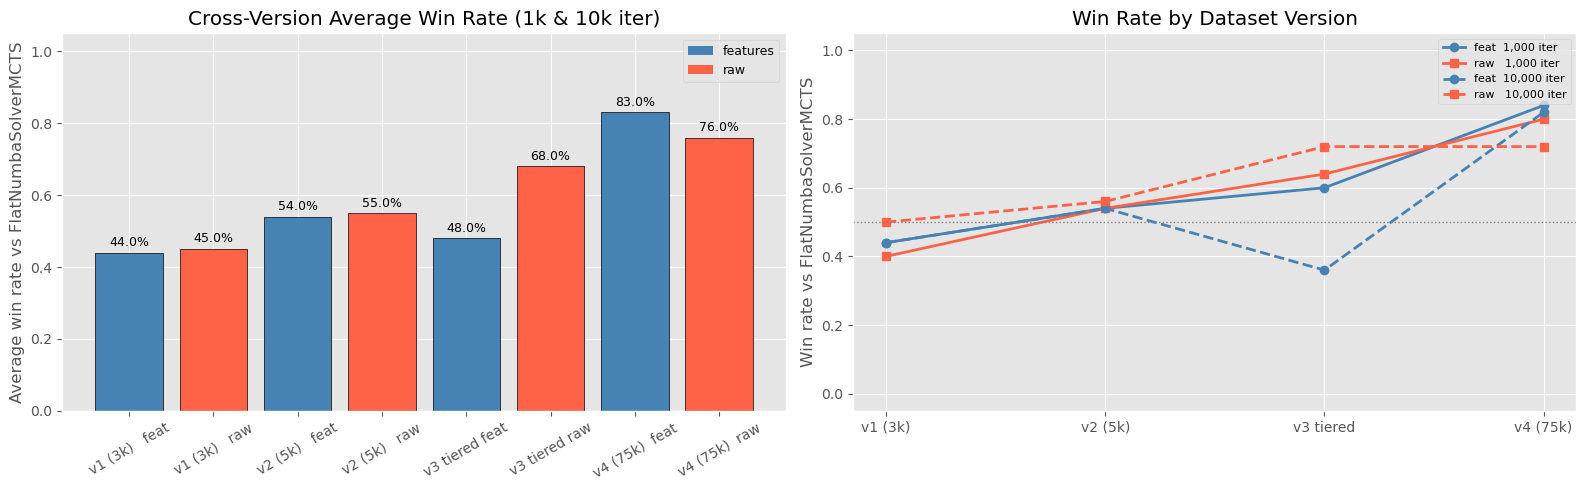

Figure saved to data/figures/cross_version_winrate.png


In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Average win rate per model across both iter counts
models  = list(VERSION_AGENTS.keys())
avg_wrs = [
    np.mean([cross_results[(m, it)][0] / CROSS_GAMES for it in CROSS_ITERS])
    for m in models
]

feat_mask = ['feat' in m for m in models]
raw_mask  = ['raw'  in m for m in models]
colors    = ['steelblue' if f else 'tomato' for f in feat_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Bar chart: average win rate per model ────────────────────────────────────
bars = axes[0].bar(models, avg_wrs, color=colors, edgecolor='black')
for bar, v in zip(bars, avg_wrs):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{v:.1%}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Average win rate vs FlatNumbaSolverMCTS')
axes[0].set_title('Cross-Version Average Win Rate (1k & 10k iter)')
axes[0].tick_params(axis='x', rotation=30)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor='steelblue', label='features'),
                         Patch(facecolor='tomato',    label='raw')], fontsize=9)

# ── Line chart: win rate per iter count, feat vs raw ─────────────────────────
version_labels = ['v1 (3k)', 'v2 (5k)', 'v3 tiered', 'v4 (75k)']
for iters, style in zip(CROSS_ITERS, ['-', '--']):
    feat_wrs = [cross_results[(m, iters)][0] / CROSS_GAMES for m in models if 'feat' in m]
    raw_wrs  = [cross_results[(m, iters)][0] / CROSS_GAMES for m in models if 'raw'  in m]
    axes[1].plot(version_labels, feat_wrs, 'o' + style, color='steelblue',
                 label=f'feat  {iters:,} iter', linewidth=2)
    axes[1].plot(version_labels, raw_wrs,  's' + style, color='tomato',
                 label=f'raw   {iters:,} iter', linewidth=2)

axes[1].set_ylim(-0.05, 1.05)
axes[1].set_ylabel('Win rate vs FlatNumbaSolverMCTS')
axes[1].set_title('Win Rate by Dataset Version')
axes[1].legend(fontsize=8)
axes[1].axhline(0.5, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig('../data/figures/cross_version_winrate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to data/figures/cross_version_winrate.png')